<a href="https://colab.research.google.com/github/afonsoamsantos-pixel/Projeto-CMO-Diabetes/blob/main/ProjetoCMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Carregar os dados
df = pd.read_csv('diabetes_preprocessed.csv')

# 2. Separar as features (X) do target (y)
X = df.drop(columns=['target']).values
y = df['target'].values

# O número de features (p)
p = X.shape[1]

print(f"✅ Dados carregados com sucesso!")
print(f"Temos {len(X)} pacientes e {p} variáveis (features) para analisar.")

✅ Dados carregados com sucesso!
Temos 442 pacientes e 10 variáveis (features) para analisar.


Este primeiro bloco de código é responsável por:

1.  **Carregar os dados:** Ele lê o arquivo `diabetes_preprocessed.csv` em um DataFrame do pandas chamado `df`.
2.  **Separar features e target:** Divide o DataFrame em `X` (as variáveis independentes ou 'features', que são as características dos pacientes) e `y` (a variável dependente ou 'target', que é o que queremos prever, neste caso, a progressão da doença).
3.  **Determinar o número de features:** Calcula o número de colunas em `X` e armazena esse valor na variável `p`.
4.  **Imprimir informações:** Exibe mensagens informando que os dados foram carregados e a quantidade de pacientes e features presentes.

In [7]:
def generate_solution(num_features):
    """
    Gera um vetor de pesos aleatório de tamanho p+1.
    """
    return np.random.uniform(-1, 1, num_features + 1)

def fitness_function(solution_vector, X, y):
    """
    Avalia os pesos calculando as previsões e o Erro Quadrático Médio (MSE).
    """
    # Separar os pesos e o bias
    w = solution_vector[:-1]
    b = solution_vector[-1]

    # Calcular y = Xw + b
    y_pred = np.dot(X, w) + b

    # Calcular o MSE
    mse = mean_squared_error(y, y_pred)

    # Devolve o negativo para o algoritmo tentar aproximar de zero (maximizar)
    return -mse

# Vamos testar se o motor está a funcionar
vetor_teste = generate_solution(p)
score = fitness_function(vetor_teste, X, y)

print(f"✅ Funções prontas!")
print(f"Vetor gerado com tamanho: {len(vetor_teste)}")
print(f"O Fitness (MSE negativo) desta solução aleatória é: {score:.2f}")

✅ Funções prontas!
Vetor gerado com tamanho: 11
O Fitness (MSE negativo) desta solução aleatória é: -29049.49


Este segundo bloco define as funções essenciais para o algoritmo de Otimização por Enxame de Partículas (PSO):

1.  **`generate_solution(num_features)`:** Esta função cria um vetor de pesos aleatório. O tamanho do vetor é `num_features + 1`, porque inclui um peso para cada feature e mais um para o termo de 'bias' (interseção) no modelo de regressão linear.
2.  **`fitness_function(solution_vector, X, y)`:** Esta é a função mais importante, pois avalia a 'qualidade' de um determinado conjunto de pesos (uma 'solução').
    *   Ela separa os pesos (`w`) e o bias (`b`) do vetor de solução.
    *   Calcula as previsões (`y_pred`) usando a fórmula de regressão linear: `y_pred = Xw + b`.
    *   Calcula o Erro Quadrático Médio (MSE) entre as previsões e os valores reais (`y`).
    *   Retorna o **negativo do MSE**. O PSO é um algoritmo de maximização, então, ao maximizar o MSE negativo, estamos efetivamente minimizando o MSE real, que é o nosso objetivo para encontrar os melhores pesos.
3.  **Teste inicial:** O código gera um vetor de teste aleatório e calcula seu 'fitness' (MSE negativo) para demonstrar que as funções estão operacionais.

In [8]:
import numpy as np

def particle_swarm_optimization(fitness_func, X, y, num_features, num_particles=30, max_iter=100):
    """
    Implementação do Particle Swarm Optimization (PSO) para encontrar os melhores pesos.
    """
    # PARÂMETROS DO PSO
    w_inertia = 0.5  # Inércia: quão rápido a partícula mantém a sua direção atual
    c1 = 1.5         # Peso cognitivo: atração para a sua própria melhor descoberta
    c2 = 1.5         # Peso social: atração para a melhor descoberta do grupo

    # 1. O LANÇAMENTO (Inicialização)
    # Criar posições (pesos) e velocidades aleatórias para os 30 exploradores
    tamanho_vetor = num_features + 1 # p pesos + 1 bias

    posicoes = np.random.uniform(-1, 1, (num_particles, tamanho_vetor))
    velocidades = np.random.uniform(-0.1, 0.1, (num_particles, tamanho_vetor))

    # Cada partícula memoriza o melhor local que ELA PRÓPRIA já visitou (pbest)
    pbest_posicoes = np.copy(posicoes)
    pbest_scores = np.array([-float('inf')] * num_particles) # Começa com a pior pontuação possível

    # O grupo memoriza o melhor local que QUALQUER UM visitou (gbest)
    gbest_posicao = None
    gbest_score = -float('inf')

    print("A iniciar o resgate (PSO)...")

    # 2. O MOVIMENTO DAS PARTÍCULAS (O Ciclo Principal)
    for iteracao in range(max_iter):

        # A Bússola: Avaliar cada partícula
        for i in range(num_particles):
            score_atual = fitness_func(posicoes[i], X, y)

            # Se encontrou um local melhor do que o seu histórico, atualiza o seu recorde pessoal (pbest)
            if score_atual > pbest_scores[i]:
                pbest_scores[i] = score_atual
                pbest_posicoes[i] = np.copy(posicoes[i])

                # Se este local for melhor do que o recorde de todo o grupo, atualiza o recorde global (gbest)
                if score_atual > gbest_score:
                    gbest_score = score_atual
                    gbest_posicao = np.copy(posicoes[i])

        # A Comunicação e Ação: Atualizar a velocidade e posição para o próximo passo
        for i in range(num_particles):
            # Fatores de aleatoriedade para não andarem todos em linha reta
            r1 = np.random.rand(tamanho_vetor)
            r2 = np.random.rand(tamanho_vetor)

            # Nova velocidade = (inércia) + (vontade de ir para o seu melhor) + (vontade de ir para o melhor do grupo)
            velocidades[i] = (w_inertia * velocidades[i] +
                              c1 * r1 * (pbest_posicoes[i] - posicoes[i]) +
                              c2 * r2 * (gbest_posicao - posicoes[i]))

            # Nova posição = Posição atual + Velocidade nova
            posicoes[i] = posicoes[i] + velocidades[i]

        # Imprimir o progresso a cada 20 iterações para não encher o ecrã
        if iteracao % 20 == 0:
            print(f"Iteração {iteracao}: Melhor Fitness Atual = {gbest_score:.4f}")

    print("Busca concluída!")
    return gbest_posicao, gbest_score

# =======================================================
# VAMOS TESTAR O ALGORITMO!
# Usa as variáveis X, y e p que já carregaste nas células anteriores.
# =======================================================
melhores_pesos, melhor_pontuacao = particle_swarm_optimization(fitness_function, X, y, num_features=p)

print(f"\n✅ O PSO terminou de treinar o modelo de Regressão Linear!")
print(f"A melhor pontuação de Erro Quadrático Médio (negativo) conseguida foi: {melhor_pontuacao:.4f}")

A iniciar o resgate (PSO)...
Iteração 0: Melhor Fitness Atual = -28807.4032
Iteração 20: Melhor Fitness Atual = -11193.4231
Iteração 40: Melhor Fitness Atual = -5974.3711
Iteração 60: Melhor Fitness Atual = -5962.9882
Iteração 80: Melhor Fitness Atual = -5927.8146
Busca concluída!

✅ O PSO terminou de treinar o modelo de Regressão Linear!
A melhor pontuação de Erro Quadrático Médio (negativo) conseguida foi: -5830.7523


Este terceiro e último bloco implementa o algoritmo principal de Otimização por Enxame de Partículas (PSO):

1.  **Parâmetros do PSO:** Define constantes como `w_inertia` (inércia, que influencia a capacidade da partícula de manter sua trajetória), `c1` (peso cognitivo, atração ao melhor ponto próprio) e `c2` (peso social, atração ao melhor ponto do enxame).
2.  **Inicialização:**
    *   Cria um conjunto de `num_particles` (partículas ou 'exploradores'), cada uma com uma posição (vetor de pesos) e velocidade iniciais aleatórias.
    *   Inicializa `pbest_posicoes` e `pbest_scores` para cada partícula (o melhor ponto que cada partícula encontrou individualmente).
    *   Inicializa `gbest_posicao` e `gbest_score` (o melhor ponto encontrado por todo o enxame).
3.  **Ciclo Principal (Iterações):** O algoritmo executa por `max_iter` iterações.
    *   **Avaliação:** Em cada iteração, a `fitness_function` é chamada para cada partícula para avaliar a qualidade de sua posição atual.
    *   **Atualização do `pbest` e `gbest`:** Se a posição atual de uma partícula for melhor que seu `pbest` anterior, ela é atualizada. Se essa nova `pbest` também for melhor que o `gbest` do enxame, o `gbest` é atualizado.
    *   **Atualização de Velocidade e Posição:** Com base nos parâmetros de inércia, `pbest` e `gbest`, a velocidade de cada partícula é ajustada. Em seguida, a nova velocidade é usada para atualizar a posição da partícula para a próxima iteração.
    *   **Progresso:** Mensagens de progresso são impressas periodicamente.
4.  **Resultado:** Após todas as iterações, o algoritmo retorna o `gbest_posicao` (os melhores pesos encontrados) e o `gbest_score` (o MSE negativo correspondente).

Em resumo, este bloco de código simula um 'enxame' de partículas que exploram o espaço de soluções (diferentes conjuntos de pesos) para encontrar o conjunto de pesos que minimiza o Erro Quadrático Médio de um modelo de regressão linear.

In [9]:
from sklearn.linear_model import LinearRegression

# Criar e treinar o modelo matemático tradicional
modelo_tradicional = LinearRegression()
modelo_tradicional.fit(X, y)

# Fazer previsões e calcular o erro
y_pred_tradicional = modelo_tradicional.predict(X)
mse_perfeito = mean_squared_error(y, y_pred_tradicional)

print(f"O Fitness (MSE negativo) perfeito da Matemática Tradicional é: {-mse_perfeito:.4f}")

O Fitness (MSE negativo) perfeito da Matemática Tradicional é: -2859.6963


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def particle_swarm_optimization_history(fitness_func, X, y, num_features, num_particles=100, max_iter=300):
    """
    PSO melhorado que guarda o histórico do melhor erro para podermos desenhar o gráfico.
    Aumentámos as partículas para 100 e as iterações para 300!
    """
    w_inertia = 0.7  # Inércia ajustada para explorar melhor no início
    c1 = 1.5
    c2 = 1.5

    tamanho_vetor = num_features + 1
    posicoes = np.random.uniform(-1, 1, (num_particles, tamanho_vetor))
    velocidades = np.random.uniform(-0.1, 0.1, (num_particles, tamanho_vetor))

    pbest_posicoes = np.copy(posicoes)
    pbest_scores = np.array([-float('inf')] * num_particles)

    gbest_posicao = None
    gbest_score = -float('inf')

    # Lista para guardar o melhor score em cada iteração
    historico_scores = []

    for iteracao in range(max_iter):
        for i in range(num_particles):
            score_atual = fitness_func(posicoes[i], X, y)

            if score_atual > pbest_scores[i]:
                pbest_scores[i] = score_atual
                pbest_posicoes[i] = np.copy(posicoes[i])

                if score_atual > gbest_score:
                    gbest_score = score_atual
                    gbest_posicao = np.copy(posicoes[i])

        for i in range(num_particles):
            r1 = np.random.rand(tamanho_vetor)
            r2 = np.random.rand(tamanho_vetor)

            velocidades[i] = (w_inertia * velocidades[i] +
                              c1 * r1 * (pbest_posicoes[i] - posicoes[i]) +
                              c2 * r2 * (gbest_posicao - posicoes[i]))

            posicoes[i] = posicoes[i] + velocidades[i]

        # Guardar o erro transformado em positivo (para o gráfico ficar mais intuitivo)
        historico_scores.append(-gbest_score)

    return gbest_posicao, gbest_score, historico_scores

print("✅ Novo PSO com memória registado!")

✅ Novo PSO com memória registado!


A lançar 100 partículas para 300 iterações...
🔥 Novo recorde alcançado: -2859.9813 (Lembrando que o limite matemático era ~ -2859)


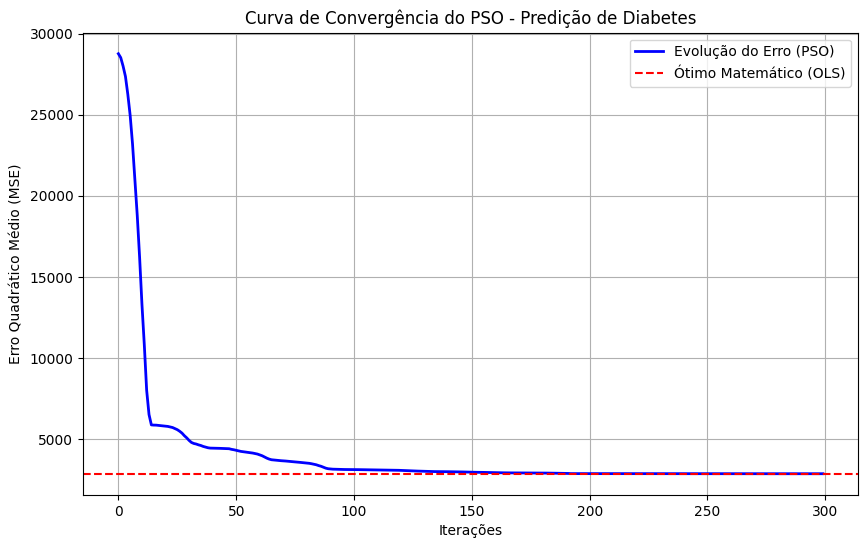

In [11]:
# 1. Executar o PSO mais potente
print("A lançar 100 partículas para 300 iterações...")
melhor_vetor, melhor_score, historico = particle_swarm_optimization_history(fitness_function, X, y, p)

print(f"🔥 Novo recorde alcançado: {melhor_score:.4f} (Lembrando que o limite matemático era ~ -2859)")

# 2. Desenhar o Gráfico de Convergência
plt.figure(figsize=(10, 6))
plt.plot(historico, color='blue', linewidth=2, label='Evolução do Erro (PSO)')

# Adicionar uma linha a tracejado com o limite perfeito para comparação
plt.axhline(y=2859.70, color='red', linestyle='--', label='Ótimo Matemático (OLS)')

plt.title('Curva de Convergência do PSO - Predição de Diabetes')
plt.xlabel('Iterações')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
import numpy as np
import pandas as pd

# Listas para guardar os resultados das 10 corridas
melhores_scores_corridas = []
melhores_pesos_corridas = []

num_execucoes = 10

print(f"🚀 A iniciar o Teste de Robustez (A executar o PSO {num_execucoes} vezes)...")

for i in range(num_execucoes):
    # Executa o PSO que já definimos antes
    vetor, score, _ = particle_swarm_optimization_history(fitness_function, X, y, p, num_particles=100, max_iter=200)

    # Guardamos o erro real (positivo) para a análise estatística
    melhores_scores_corridas.append(-score)
    melhores_pesos_corridas.append(vetor)
    print(f"  Corrida {i+1}/{num_execucoes} concluída. MSE: {-score:.4f}")

# --- ANÁLISE ESTATÍSTICA ---
media_mse = np.mean(melhores_scores_corridas)
desvio_padrao_mse = np.std(melhores_scores_corridas)

print("\n" + "="*50)
print("📊 RESULTADOS ESTATÍSTICOS DO PSO (Para o Relatório)")
print("="*50)
print(f"Média do MSE: {media_mse:.4f}")
print(f"Desvio Padrão do MSE: {desvio_padrao_mse:.4f}")
print(f"Melhor MSE absoluto conseguido: {min(melhores_scores_corridas):.4f}")
print(f"Ótimo Matemático de referência (OLS): 2859.6963")
print("="*50)

# --- MAPEAR OS PESOS DA MELHOR CORRIDA ---
# Encontrar o índice da corrida que teve o menor erro (melhor performance)
melhor_corrida_idx = np.argmin(melhores_scores_corridas)
melhor_vetor_global = melhores_pesos_corridas[melhor_corrida_idx]

# Ir buscar os nomes originais das colunas (features) do teu dataset
df_original = pd.read_csv('diabetes_preprocessed.csv')
nomes_features = list(df_original.drop(columns=['target']).columns)
nomes_features.append("Intercept (Bias)") # O último elemento do vetor é o bias

print("\n🧬 PESOS ÓTIMOS DESCOBERTOS PELO TEU PSO:")
print("-" * 50)
for nome, peso in zip(nomes_features, melhor_vetor_global):
    print(f"{nome:<25} : {peso:.6f}")
print("-" * 50)


🚀 A iniciar o Teste de Robustez (A executar o PSO 10 vezes)...
  Corrida 1/10 concluída. MSE: 2864.4605
  Corrida 2/10 concluída. MSE: 2859.8252
  Corrida 3/10 concluída. MSE: 2859.7909
  Corrida 4/10 concluída. MSE: 2861.7988
  Corrida 5/10 concluída. MSE: 2860.2036
  Corrida 6/10 concluída. MSE: 2859.8759
  Corrida 7/10 concluída. MSE: 2859.7900
  Corrida 8/10 concluída. MSE: 2927.7490
  Corrida 9/10 concluída. MSE: 2861.3011
  Corrida 10/10 concluída. MSE: 2860.7301

📊 RESULTADOS ESTATÍSTICOS DO PSO (Para o Relatório)
Média do MSE: 2867.5525
Desvio Padrão do MSE: 20.1123
Melhor MSE absoluto conseguido: 2859.7900
Ótimo Matemático de referência (OLS): 2859.6963

🧬 PESOS ÓTIMOS DESCOBERTOS PELO TEU PSO:
--------------------------------------------------
age                       : -8.041828
sex                       : -239.780825
bmi                       : 519.985372
bp                        : 323.445636
s1                        : -747.129484
s2                        : 440.874659
s